In [ ]:
from IPython.display import HTML
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 50)
sns.set()
%matplotlib inline

In [ ]:
path= 'Loan_Default.csv'
data= pd.read_csv(path)
df= data.copy()

## EDA

In [3]:
df.shape

(148670, 34)

In [4]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [5]:
df.dtypes.value_counts()

object     21
float64     8
int64       5
Name: count, dtype: int64

<Figure size 1200x600 with 0 Axes>

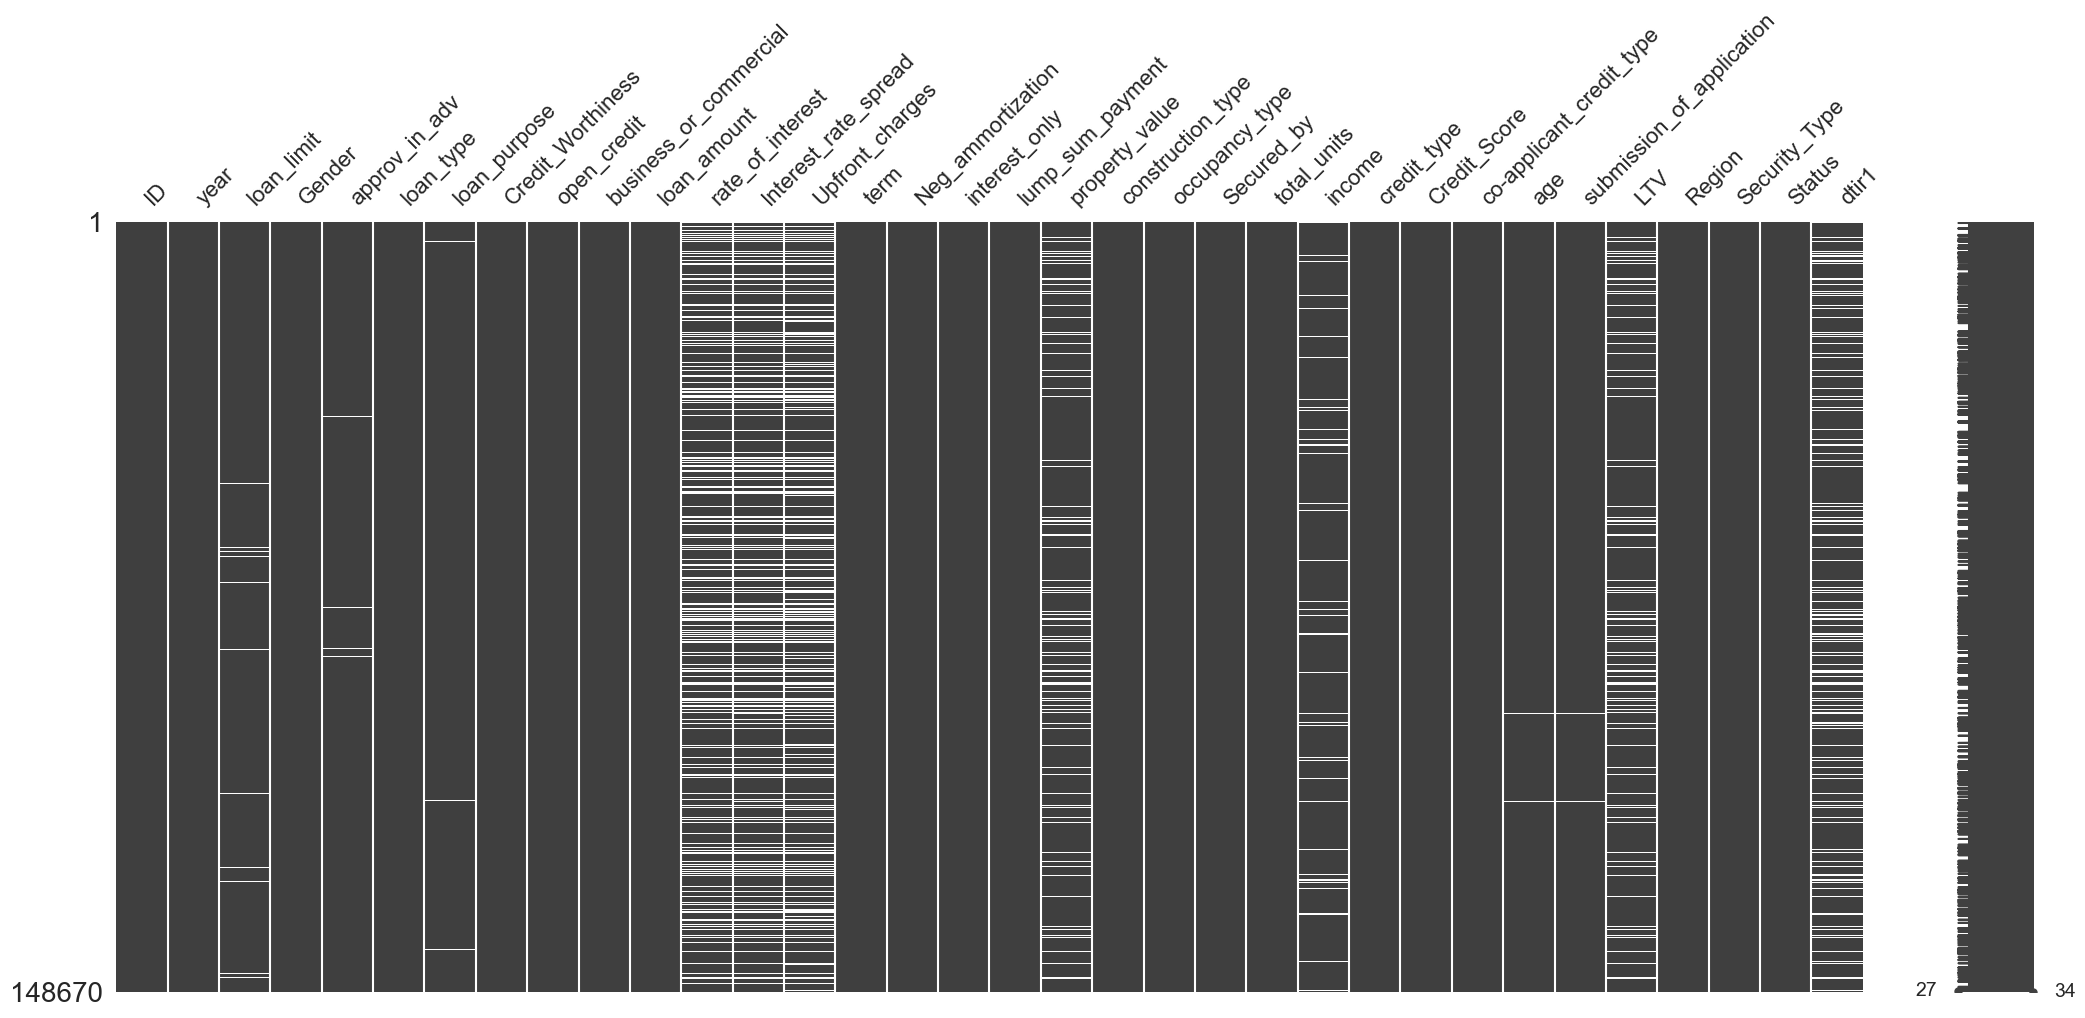

In [6]:
import missingno
plt.figure(figsize= (12, 6))
missingno.matrix(df)
plt.show()

In [7]:
mask= df.isna().sum().sort_values(ascending= False) > 0
df.isna().sum().sort_values(ascending= False)[mask]

Upfront_charges              39642
Interest_rate_spread         36639
rate_of_interest             36439
dtir1                        24121
LTV                          15098
property_value               15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
submission_of_application      200
age                            200
loan_purpose                   134
Neg_ammortization              121
term                            41
dtype: int64

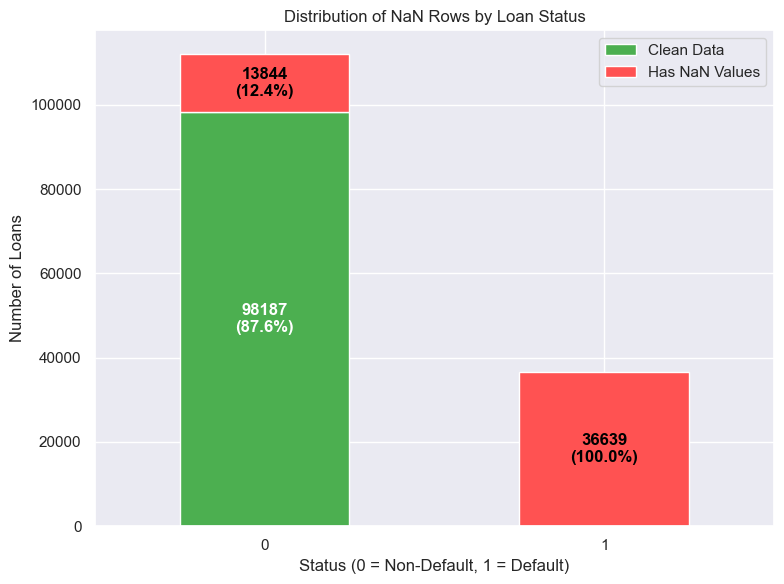

In [8]:
df['has_nan'] = df.isna().any(axis=1)
plot_data = df.groupby(['Status', 'has_nan']).size().unstack(fill_value=0)
totals = plot_data.sum(axis=1)

# 2. Plot Bars
ax = plot_data.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF5252'], figsize=(8, 6))

# 3. Fixed Labeling Logic
for i, status in enumerate(plot_data.index):
    cumulative_height = 0
    for column in plot_data.columns:
        val = plot_data.loc[status, column]
        if val > 0:
            percentage = (val / totals[status]) * 100
            # Position text in the middle of the current segment
            y_pos = cumulative_height + (val / 2)
            
            # Dynamic color for readability (White on green, Black on red)
            text_color = 'white' if column == False else 'black'
            
            ax.text(i, y_pos, f'{val}\n({percentage:.1f}%)', 
                    ha='center', va='center', 
                    color=text_color, fontweight='bold')
        
        cumulative_height += val

plt.title('Distribution of NaN Rows by Loan Status')
plt.xlabel('Status (0 = Non-Default, 1 = Default)')
plt.ylabel('Number of Loans')
plt.legend(['Clean Data', 'Has NaN Values'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fixed_nan_status_plot.png')

**Because the data with nan values all represents those that defaulted, we must clean it to train the model**

**Questions to ask**

In [9]:
# what does the data represents > unknown
# where was the data collected, when, how. > 2019, each row is a unique loan given to some person(x)
# we don't know were it was collected
# is it relevant to use all cols ? > perhaps not, many might be correlated, we'll investigate

In [10]:
# duplicates:
# target y:
# corr:
# pairplots:
# domain knowledge engineer features to check the data is valid (consistent with real-world trends)
# > frequency bars (def/non-def) and pie charts

In [11]:
relevant_cols= ['loan_limit','approv_in_adv','Gender','loan_type','loan_purpose',
                'loan_amount','rate_of_interest','term','Neg_ammortization','lump_sum_payment',
                'occupancy_type','Secured_by','income','Credit_Score','age',
                 'submission_of_application','LTV','Region','Security_Type','dtir1']

In [12]:
flag_identifier= ['Gender','Region','income','Credit_Score','Credit_Worthiness','age']
print('nb of duplicates:',df.duplicated().sum())
print('nb of people taking on multiple loans at once:',
df.duplicated(subset= ['Gender','Region','income','Credit_Score','Credit_Worthiness','age']).sum())

nb of duplicates: 0
nb of people taking on multiple loans at once: 6171


In [13]:
# adding an identifier to flag those who took multiple loans at once.
df['count']= df.groupby(flag_identifier, dropna= False)['ID'].transform('count')

In [14]:
# 1. Get the counts of missing values (your existing logic)
nan_counts = df.isna().sum().sort_values(ascending=False)
mask = nan_counts > 0
nan_series = nan_counts[mask]

# 2. Calculate the Default vs Non-Default percentages for those specific columns
# We iterate only through columns that have NaNs
results = []
for col in nan_series.index:
    # Filter for rows where THIS specific column is NaN
    nan_rows = df[df[col].isna()]
    
    # Calculate percentages of Status
    stats = nan_rows['Status'].value_counts(normalize=True) * 100
    results.append({
        'Column': col,
        'NaN Count': nan_series[col],
        'Non-Default % (0)': stats.get(0, 0),
        'Default % (1)': stats.get(1, 0)
    })

# 3. Display as a single clean table
summary_table = pd.DataFrame(results).set_index('Column')
print(summary_table.round(2))

                           NaN Count  Non-Default % (0)  Default % (1)
Column                                                                
Upfront_charges                39642               7.96          92.04
Interest_rate_spread           36639               0.00         100.00
rate_of_interest               36439               0.00         100.00
dtir1                          24121              32.38          67.62
LTV                            15098               0.01          99.99
property_value                 15098               0.01          99.99
income                          9150              86.46          13.54
loan_limit                      3344              73.65          26.35
approv_in_adv                    908              73.46          26.54
submission_of_application        200               0.00         100.00
age                              200               0.00         100.00
loan_purpose                     134              73.88          26.12
Neg_am

**imputing LTV/property_value**
+ procedure: group loan_amounts into bins
+ check their ltv percentage of property_value
+ impute the pv, and the ltv for missings

In [15]:
from optbinning import OptimalBinning

# 1. Initialize for a specific column
optb = OptimalBinning(name="loan_amount", dtype="numerical", solver="cp")

# 2. Fit the data (automatically handles your missing values)
optb.fit(df["loan_amount"].values, df["Status"].values)

# 3. Get the WoE table and Information Value (IV)
binning_table = optb.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 111500.00)",10030,0.067465,6515,3515,0.350449,-0.500595,0.018914,0.002340
1,"[111500.00, 141500.00)",8396,0.056474,5946,2450,0.291806,-0.231032,0.003187,0.000397
2,"[141500.00, 171500.00)",10075,0.067768,7216,2859,0.283772,-0.191834,0.002613,0.000326
3,"[171500.00, 201500.00)",9825,0.066086,7184,2641,0.268804,-0.116964,0.000931,0.000116
4,"[201500.00, 221500.00)",8259,0.055553,6187,2072,0.250878,-0.023726,0.000031,0.000004
5,"[221500.00, 281500.00)",22198,0.149311,16791,5407,0.243581,0.015486,0.000036,0.000004
6,"[281500.00, 311500.00)",10120,0.068070,7746,2374,0.234585,0.064938,0.000282,0.000035
7,"[311500.00, 341500.00)",8788,0.059111,6786,2002,0.227811,0.103053,0.000611,0.000076
8,"[341500.00, 431500.00)",22742,0.152970,17794,4948,0.217571,0.162215,0.003858,0.000482
9,"[431500.00, 521500.00)",17655,0.118753,13975,3680,0.208440,0.216695,0.005266,0.000657


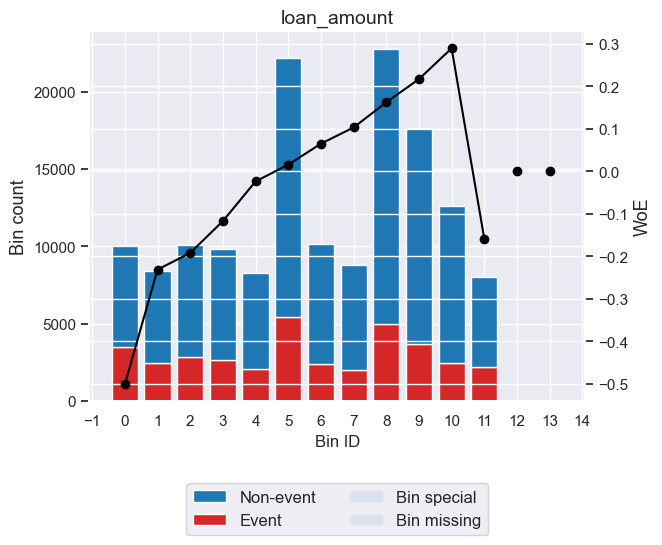

In [16]:
binning_table.plot(metric='woe')
plt.show()

In [17]:
bins = np.concatenate(([-np.inf], optb.splits, [np.inf]))
df['loan_amount_bins']= pd.cut(df['loan_amount'], bins= bins)

In [18]:
df.groupby('loan_amount_bins')[['property_value','LTV']].median()

C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\276312229.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('loan_amount_bins')[['property_value','LTV']].median()


,property_value,LTV
loan_amount_bins,,
"(-inf, 111500.0]",138000.0,64.204545
"(111500.0, 141500.0]",178000.0,71.067416
"(141500.0, 171500.0]",218000.0,73.989899
"(171500.0, 201500.0]",248000.0,76.162791
"(201500.0, 221500.0]",288000.0,74.280576
"(221500.0, 281500.0]",328000.0,76.580460
"(281500.0, 311500.0]",388000.0,76.417526
"(311500.0, 341500.0]",428000.0,77.573529
"(341500.0, 431500.0]",508000.0,76.433692


In [19]:
#LTV  loan_amunt / property_value * 100
ltv_na= df['LTV'].isna()
print('LTV values that cannot be imputed normally:', df[ltv_na][['loan_amount','property_value']].isna().any(axis= 1).sum())
print('LTV values that can be imputed :', df[ltv_na][['loan_amount','property_value']].notna().all(axis= 1).sum())

LTV values that cannot be imputed normally: 15098
LTV values that can be imputed : 0


In [20]:
df['ltv_median']= df.groupby('loan_amount_bins', dropna= False)['LTV'].transform('median')

C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\4125649518.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['ltv_median']= df.groupby('loan_amount_bins', dropna= False)['LTV'].transform('median')


In [21]:
def pv_imputer(x):
    return (x['loan_amount'] / x['ltv_median']) *100
df.loc[ltv_na, 'property_value']= df[ltv_na].apply(pv_imputer, axis= 1)
df['LTV']= df['LTV'].fillna((df['loan_amount']/df['property_value'])*100)

In [22]:
df[['LTV','property_value']].isna().sum()

LTV               0
property_value    0
dtype: int64

**Imputing Income Variable**
+ process: using loan_amount bins we find median income of indv
+ for each slice we impute the income accordingly

In [23]:
income_na= df['income'].isna()
df['income_median']= df.groupby('loan_amount_bins', dropna= False)['income'].transform('median')
df.loc[income_na, 'income']= df.loc[income_na, 'income_median']

C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\554647925.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['income_median']= df.groupby('loan_amount_bins', dropna= False)['income'].transform('median')


**Imputing dtir1**

In [24]:
#dtir1  'loan_amont / income'
dtir_na= df['dtir1'].isna()
print('dtir1 values that cannot be imputed normally:',df[dtir_na][['loan_amount','income']].isna().any(axis= 1).sum())
print('dtir1 values that can be imputed:',df[dtir_na][['loan_amount','income']].notna().all(axis= 1).sum() )

dtir1 values that cannot be imputed normally: 0
dtir1 values that can be imputed: 24121


In [25]:
# starting with normal imputations. loan_amount / income * 100
mask= df[dtir_na][['loan_amount','income']].notna().all(axis= 1)
dtir_na_normalimp= mask[mask].index
df.loc[dtir_na_normalimp, 'dtir1']= (df.loc[dtir_na_normalimp, 'loan_amount'] / df.loc[dtir_na_normalimp, 'income'])*100

**Imputing loan_limit variable**

In [26]:
from IPython.display import display, HTML

# 1. Generate the descriptions
ncf_desc = df[df['loan_limit'] == 'ncf']['loan_amount'].describe().round(2).to_frame(name='NCF')
cf_desc = df[df['loan_limit'] == 'cf']['loan_amount'].describe().round(2).to_frame(name='CF')

# 2. Display as HTML side-by-side
display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div><h3>NCF Loan Amounts</h3>{ncf_desc.to_html()}</div>
    <div><h3>CF Loan Amounts</h3>{cf_desc.to_html()}</div>
</div>
"""))

,NCF
count,9978.00
mean,522270.70
std,342595.25
min,36500.00
25%,246500.00
50%,486500.00
75%,726500.00
max,3576500.00
,CF
count,135348.00


In [27]:
loan_limit_na= df['loan_limit'].isna()
max_cf= df[df['loan_limit']== 'ncf']['loan_amount'].max()
def impute_loan_limit(x):
    if x['loan_amount']>max_cf:
        return 'ncf'
    else :
        return 'cf'
df.loc[loan_limit_na, 'loan_limit']= df.loc[loan_limit_na].apply(impute_loan_limit, axis= 1) 

**Imputing approv_in_adv Variable**

In [28]:
# 1. Generate descriptive statistics for 'nopre' and 'pre'
nopre_desc = df[df['approv_in_adv'] == 'nopre']['Credit_Score'].describe().round(2).to_frame(name='No Pre-Approval')
pre_desc = df[df['approv_in_adv'] == 'pre']['Credit_Score'].describe().round(2).to_frame(name='Pre-Approval')


display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div><h3>Nopre (No Pre-Approval)</h3>{nopre_desc.to_html()}</div>
    <div><h3>Pre (Pre-Approval)</h3>{pre_desc.to_html()}</div>
</div>
"""))

,No Pre-Approval
count,124621.00
mean,699.84
std,115.87
min,500.00
25%,599.00
50%,699.00
75%,800.00
max,900.00
,Pre-Approval
count,23141.00


In [29]:
# 1. Process 'nopre' group
nopre_stats = df[df['approv_in_adv'] == 'nopre']['Status'].value_counts()
nopre_table = pd.concat([nopre_stats, (nopre_stats/nopre_stats.sum()*100).round(2)], axis=1)
nopre_table.columns = ['Count', 'Percentage (%)']

# 2. Process 'pre' group
pre_stats = df[df['approv_in_adv'] == 'pre']['Status'].value_counts()
pre_table = pd.concat([pre_stats, (pre_stats/pre_stats.sum()*100).round(2)], axis=1)
pre_table.columns = ['Count', 'Percentage (%)']

display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div><h3>No Pre-Approval</h3>{nopre_table.to_html()}</div>
    <div><h3>Pre-Approval</h3>{pre_table.to_html()}</div>
</div>
"""))

,Count,Percentage (%)
Status,,
0,93058,74.67
1,31563,25.33
,Count,Percentage (%)
Status,,
0,18306,79.11
1,4835,20.89


In [30]:
# setting the defaulters nan to nopre, the non-defaulters to pre
aid_na= df['approv_in_adv'].isna()
def impute_aid(x):
    if x['Status']== 0:
        return 'pre'
    else :
        return 'nopre'
df.loc[aid_na, 'approv_in_adv']= df.apply(impute_aid, axis= 1)

**Imputing Age**
+ process: creating 25%-75% quantile range around the income for each age group
+ then if our missing person's income lies in some interval impute its age group with the respective one.

In [31]:
# 1. Keep your existing age_stats for the first attempt
age_medians = df.groupby('age')['income'].median()
age_stats = df.groupby('age')['income'].quantile([0.25, 0.75]).unstack()
age_stats.columns = ['q1', 'q3']

# 2. Improved Function: Try Range first, then closest Median
def find_matching_age_fixed(income):
    if pd.isna(income): return None
    
    # Attempt 1: Check if within Q1-Q3 range
    match = age_stats[(income >= age_stats['q1']) & (income <= age_stats['q3'])]
    if not match.empty:
        return match.index[0]
    
    # Attempt 2: If no range match, find the age with the closest median income
    # (income - age_medians).abs() calculates the distance; idxmin() finds the smallest gap
    return (age_medians - income).abs().idxmin()

# 3. Apply to remaining missing values
age_na = df['age'].isna()
df.loc[age_na, 'age'] = df.loc[age_na, 'income'].apply(find_matching_age_fixed)

**Imputing submission_of_application Variable**
+ process: using the common category for each status type

In [32]:
# 1. Process 'to_inst' group
to_inst_stats = df[df['submission_of_application'] == 'to_inst']['Status'].value_counts()
to_inst_table = pd.concat([to_inst_stats, (to_inst_stats/to_inst_stats.sum()*100).round(2)], axis=1)
to_inst_table.columns = ['Count', 'Percentage (%)']

# 2. Process 'not_inst' group
not_inst_stats = df[df['submission_of_application'] == 'not_inst']['Status'].value_counts()
not_inst_table = pd.concat([not_inst_stats, (not_inst_stats/not_inst_stats.sum()*100).round(2)], axis=1)
not_inst_table.columns = ['Count', 'Percentage (%)']

display(HTML(f"""
<div style="display: flex; gap: 50px;">
    <div><h3>To Institution (to_inst)</h3>{to_inst_table.to_html()}</div>
    <div><h3>Not to Institution (not_inst)</h3>{not_inst_table.to_html()}</div>
</div>
"""))

,Count,Percentage (%)
Status,,
0,68601,71.6
1,27213,28.4
,Count,Percentage (%)
Status,,
0,43430,82.48
1,9226,17.52


In [33]:
# it seems installment based loans are more likely to default
soa_na= df['submission_of_application'].isna()
def impute_soa(x):
    if x['Status'] == 0:
        return 'not_inst'
    else :
        return 'to_inst'
df.loc[soa_na, 'submission_of_application']= df.apply(impute_soa, axis= 1)

**Imputing loan_purpose Variable**
+ process: using the common category for each status type

In [34]:
purposes = ['p1', 'p2', 'p3', 'p4']
html_blocks = ""

# 2. Loop through categories to create tables
for p in purposes:
    stats = df[df['loan_purpose'] == p]['Status'].value_counts()
    
    # Create combined table (Count + %)
    table = pd.concat([stats, (stats/stats.sum()*100).round(2)], axis=1)
    table.columns = ['Count', 'Percentage (%)']
    
    # Append to HTML string
    html_blocks += f"<div><h3>Purpose: {p}</h3>{table.to_html()}</div>"

# 3. Display all side-by-side
display(HTML(f"""
<div style="display: flex; gap: 30px; flex-wrap: wrap;">
    {html_blocks}
</div>
"""))

,Count,Percentage (%)
Status,,
0,25594,74.12
1,8935,25.88
,Count,Percentage (%)
Status,,
0,2191,66.92
1,1083,33.08
,Count,Percentage (%)
Status,,
0,41938,74.98


In [35]:
lp_na= df['loan_purpose'].isna()
def impute_lp(x):
    if x['Status'] == 0:
        return 'p4' #home investment
    else :
        return 'p3' #debt consolidation -likely to default
df.loc[lp_na, 'loan_purpose']= df.apply(impute_lp, axis= 1)

**Impute Neg_ammortization Variable**

In [36]:
# 1. Define the categories
neg_labels = ['not_neg', 'neg_amm']
html_blocks = ""

# 2. Loop through categories to create tables
for label in neg_labels:
    stats = df[df['Neg_ammortization'] == label]['Status'].value_counts()
    
    # Create combined table (Count + %)
    table = pd.concat([stats, (stats/stats.sum()*100).round(2)], axis=1)
    table.columns = ['Count', 'Percentage (%)']
    
    # Append to HTML string
    html_blocks += f"<div><h3>Amortization: {label}</h3>{table.to_html()}</div>"

# 3. Display side-by-side
from IPython.display import display, HTML
display(HTML(f"""
<div style="display: flex; gap: 50px; flex-wrap: wrap;">
    {html_blocks}
</div>
"""))

,Count,Percentage (%)
Status,,
0,103560,77.62
1,29860,22.38
,Count,Percentage (%)
Status,,
0,8382,55.4
1,6747,44.6


In [37]:
neg_amo_na= df['Neg_ammortization'].isna()
def impute_neg_amo(x):
    if x['Status'] == 0:
        return 'neg_amm'
    else :
        return 'not_neg'
df.loc[neg_amo_na, 'Neg_ammortization']= df.apply(impute_neg_amo, axis= 1)

**Imputing Term Variable**
+ process: those with missing term we check their income & loan amount, and we act accordingly
+ low income and high loan usually means long term and vice versa.

In [38]:
# 1. Define the Status types
status_types = df['Status'].unique()
html_blocks = ""

# 2. Loop through each Status to describe the 'term' column
for s in sorted(status_types):
    # Calculate descriptive stats for the specific status
    stats = df[df['Status'] == s]['term'].describe().round(2).to_frame(name='Stats')
    
    # Append to HTML string
    html_blocks += f"<div><h3>Status: {s} (Term)</h3>{stats.to_html()}</div>"

# 3. Display side-by-side
from IPython.display import display, HTML
display(HTML(f"""
<div style="display: flex; gap: 50px; flex-wrap: wrap;">
    {html_blocks}
</div>
"""))

,Stats
count,112005.00
mean,335.14
std,58.82
min,96.00
25%,360.00
50%,360.00
75%,360.00
max,360.00
,Stats
count,36624.00


In [39]:
# 1. Calculate the 25th and 75th percentiles for both features per term
stats = df.groupby('term')[['loan_amount', 'income']].quantile([0.25, 0.75]).unstack()

# 2. Function to find a matching term based on interval logic
def find_term_by_interval(row):
    # Iterate through each known term to see if the row fits the 'typical' profile
    for term in stats.index:
        # Check loan_amount interval
        la_q1, la_q3 = stats.loc[term, ('loan_amount', 0.25)], stats.loc[term, ('loan_amount', 0.75)]
        # Check income interval
        inc_q1, inc_q3 = stats.loc[term, ('income', 0.25)], stats.loc[term, ('income', 0.75)]
        
        if (la_q1 <= row['loan_amount'] <= la_q3) and (inc_q1 <= row['income'] <= inc_q3):
            return term
    return None # Return None if no clear match is found

# 3. Identify NaN rows and apply the logic
term_na = df['term'].isna()
df.loc[term_na, 'term'] = df[term_na].apply(find_term_by_interval, axis=1)

# 4. Optional: Fill remaining with the global median if intervals were too strict
df['term'] = df['term'].fillna(df['term'].median())

**Imputing Upfront_charges Variable**
+ process using median for each loan_purpose type

In [40]:
upfront_charges_na= df['Upfront_charges'].isna()
uc_dict= dict(df.groupby('loan_purpose')['Upfront_charges'].median())
def impute_uc(x):
    return uc_dict[x['loan_purpose']]
df.loc[upfront_charges_na, 'Upfront_charges']= df.loc[upfront_charges_na].apply(impute_uc, axis= 1)

**Imputing rate_of_interest Variable**
+ process: using xgboost (treating int_rate as y)

In [41]:
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, root_mean_squared_error as rmse
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split as tts
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

In [42]:
mask= df['Status'] == 0
cols_of_interest_train= df.loc[mask, ['income','loan_purpose','age','loan_amount','term',
                   'lump_sum_payment','property_value','Secured_by', 'Credit_Score', 'count','LTV','dtir1']]
target_impute= df.loc[mask, 'rate_of_interest']
cols_of_interest_predict= df.loc[~mask, ['income','loan_purpose','age','loan_amount','term',
                   'lump_sum_payment','property_value','Secured_by', 'Credit_Score', 'count','LTV','dtir1']]
x_train, x_test, y_train, y_test= tts(cols_of_interest_train, target_impute, random_state= 22,
                                      test_size= .2)

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.02096e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.03591e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.05681e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.02038e-16): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.03573e-16): result may not be accurate.
  r

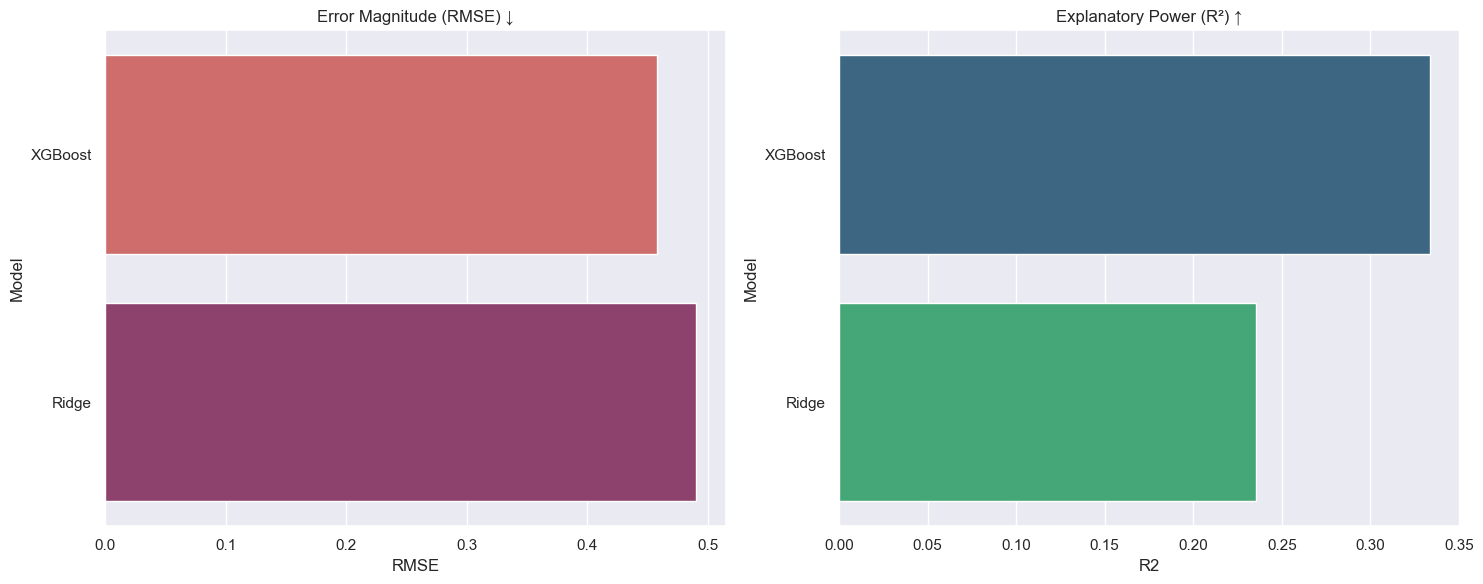

In [43]:
# 1. Preprocessing: One-Hot Encode all categorical columns (including age)
# This converts labels like '<25' into binary columns the models can read
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), 
         ['age', 'loan_purpose', 'lump_sum_payment', 'Secured_by', 'term'])
    ], remainder='passthrough')

x_train_proc = preprocessor.fit_transform(x_train)
x_test_proc = preprocessor.transform(x_test)

# 2. Model Optimization via Grid Search
ridge_gs = GridSearchCV(Ridge(), {'alpha': [0.1, 1.0, 10.0]}, cv=3, scoring='r2').fit(x_train_proc, y_train)
xgb_gs = GridSearchCV(XGBRegressor(), {'n_estimators': [100], 'max_depth': [3, 5]}, cv=3, scoring='r2').fit(x_train_proc, y_train)

# 3. Evaluation
results = []
for name, model in {'Ridge': ridge_gs, 'XGBoost': xgb_gs}.items():
    preds = model.predict(x_test_proc)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, preds),
        'RMSE': rmse(y_test, preds)
    })

res_df = pd.DataFrame(results)

# 4. Visualization: Side-by-Side Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Left Plot: RMSE (Lower is Better)
sns.barplot(x='RMSE', y='Model', data=res_df.sort_values('RMSE'), palette='flare', ax=ax1)
ax1.set_title('Error Magnitude (RMSE) ↓')

# Right Plot: R2 (Higher is Better)
sns.barplot(x='R2', y='Model', data=res_df.sort_values('R2', ascending=False), palette='viridis', ax=ax2)
ax2.set_title('Explanatory Power (R²) ↑')

plt.tight_layout()
plt.show()

In [44]:
# 1. Transform the raw prediction data using the fitted preprocessor
# This converts it into the exact numerical format the model expects
x_predict_proc = preprocessor.transform(cols_of_interest_predict)

# 2. Generate the predictions
imputed_rates = xgb_gs.best_estimator_.predict(x_predict_proc)

# 3. Fill the NaNs in the original dataframe
# Using the index of cols_of_interest_predict ensures values go to the right rows
df.loc[cols_of_interest_predict.index, 'rate_of_interest'] = imputed_rates

# 4. Verify no NaNs remain
print(f"Remaining NaNs in rate_of_interest: {df['rate_of_interest'].isna().sum()}")

Remaining NaNs in rate_of_interest: 0


**Imputing Interest_rate_spread Variable**
+ Same Process

In [45]:
from sklearn.preprocessing import StandardScaler

C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\2512923825.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=res_df.sort_values('RMSE'), palette='flare', ax=ax1)
C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\2512923825.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=res_df.sort_values('R2', ascending=False), palette='viridis', ax=ax2)


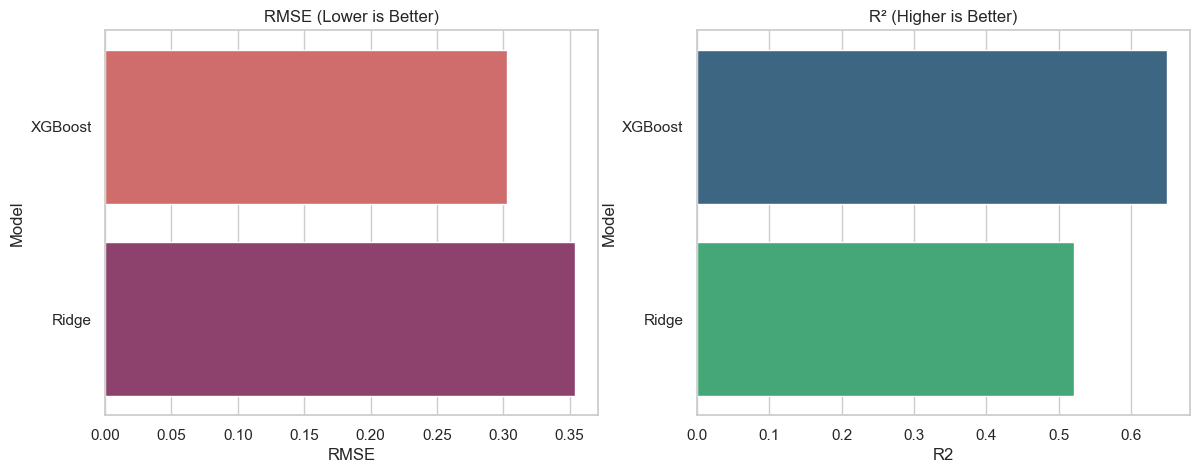

Prediction complete. Remaining NaNs in Interest_rate_spread: 0


In [46]:
# Replace infinities and fill NaNs in the source dataframe to prevent missing output
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Identify numeric and categorical columns automatically
target = 'Interest_rate_spread'
exclude = [target, 'rate_of_interest', 'Status']
X_all = df.drop(columns=exclude)

num_cols = X_all.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_all.select_dtypes(include=['object', 'bool']).columns.tolist()

# Fill NaNs in the actual dataframe so no rows are skipped during prediction
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. DEFINE TRAINING SET
train_mask = (df['Status'] == 0) & (df[target].notna())
X = df.loc[train_mask, num_cols + cat_cols]
y = df.loc[train_mask, target]

# 3. PREPROCESSING PIPELINE
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

X_train, X_test, y_train, y_test = tts(X, y, test_size=0.2, random_state=22)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# 4. GRID SEARCH
ridge_gs = GridSearchCV(Ridge(), {'alpha': [0.1, 1.0, 10.0]}, cv=3, scoring='r2').fit(X_train_proc, y_train)
xgb_gs = GridSearchCV(XGBRegressor(), {'n_estimators': [100], 'max_depth': [3, 5]}, cv=3, scoring='r2').fit(X_train_proc, y_train)

# 5. VISUALIZATION
results = []
for name, gs in {'Ridge': ridge_gs, 'XGBoost': xgb_gs}.items():
    p = gs.predict(X_test_proc)
    results.append({'Model': name, 'R2': r2_score(y_test, p), 'RMSE': rmse(y_test, p)})

res_df = pd.DataFrame(results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='RMSE', y='Model', data=res_df.sort_values('RMSE'), palette='flare', ax=ax1)
ax1.set_title('RMSE (Lower is Better)')
sns.barplot(x='R2', y='Model', data=res_df.sort_values('R2', ascending=False), palette='viridis', ax=ax2)
ax2.set_title('R² (Higher is Better)')
plt.show()

# 6. PREDICT FOR DEFAULTERS (Status == 1)
defaulter_mask = df['Status'] == 1
X_def = df.loc[defaulter_mask, num_cols + cat_cols]
X_def_proc = preprocessor.transform(X_def)

# Use the best model to fill the missing spread values
df.loc[defaulter_mask, target] = xgb_gs.best_estimator_.predict(X_def_proc)

print(f"Prediction complete. Remaining NaNs in {target}: {df[target].isna().sum()}")

In [47]:
df.isna().sum().sum()

0

In [48]:
df.head(3)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,has_nan,count,loan_amount_bins,ltv_median,income_median
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,4.322824,0.808717,1755.49,360.0,not_neg,not_int,not_lpsm,118000.000000,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.000000,True,1,"(111500.0, 141500.0]",71.067416,3120.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,3.981846,1.061626,1755.49,360.0,not_neg,not_int,lpsm,277999.999998,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,74.280576,North,direct,1,4146.586345,True,1,"(201500.0, 221500.0]",74.280576,4380.0
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.560000,0.200000,595.00,360.0,neg_amm,not_int,not_lpsm,508000.000000,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.000000,False,1,"(341500.0, 431500.0]",76.433692,6720.0


## Feature Selection

+ Information Value
+ Tree based feature importance
+ domain knowledge

In [49]:
drop_cols= ['ID','year', 'has_nan','loan_amount_bins','ltv_median','income_median']
df_new= df.drop(drop_cols, axis= 1)

In [50]:
from optbinning import BinningProcess

In [51]:
feat_names= [col for col in df_new.columns if col != 'Status']
opt= BinningProcess(variable_names= feat_names,
                    selection_criteria={"iv": {"min": 0.02}})
opt.fit(df_new[feat_names], df_new['Status'])

,variable_names,"['loan_limit', 'Gender', ...]"
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,{'iv': {'min': 0.02}}
,fixed_variables,None


In [52]:
mask= opt.summary()['selected'] == True
opt.summary()[mask].sort_values('iv', ascending= False)

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
11,Upfront_charges,numerical,OPTIMAL,True,7,6.377676,0.420945,0.868234,0.0
22,credit_type,categorical,OPTIMAL,True,4,4.715143,0.172529,0.421691,0.0
30,dtir1,numerical,OPTIMAL,True,10,1.011161,0.11454,0.485558,0.091207
9,rate_of_interest,numerical,OPTIMAL,True,5,0.354281,0.038917,0.195647,0.586292
27,LTV,numerical,OPTIMAL,True,8,0.189564,0.023339,0.219734,0.492678
21,income,numerical,OPTIMAL,True,9,0.159316,0.019155,0.190164,0.349841
24,co-applicant_credit_type,categorical,OPTIMAL,True,2,0.113938,0.014172,0.167354,0.303609
13,Neg_ammortization,categorical,OPTIMAL,True,2,0.110164,0.013386,0.108535,0.108182
16,property_value,numerical,OPTIMAL,True,7,0.088187,0.0109,0.15993,0.02375
26,submission_of_application,categorical,OPTIMAL,True,2,0.085836,0.010668,0.135852,0.213058


In [53]:
iv_obtained_cols= opt.summary().loc[mask, 'name'].values

**tree based feature importance**

In [54]:
df_new.head(2)

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,count
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,4.322824,0.808717,1755.49,360.0,not_neg,not_int,not_lpsm,118000.000000,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.000000,1
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,3.981846,1.061626,1755.49,360.0,not_neg,not_int,lpsm,277999.999998,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,74.280576,North,direct,1,4146.586345,1


In [55]:
age_order= ['<25','25-34', '35-44', '45-54', '55-64', '65-74', '>74']
ohe_cols= ['Gender','approv_in_adv', 'loan_type', 'loan_purpose',
           'Credit_Worthiness', 'open_credit', 'business_or_commercial','Neg_ammortization', 'interest_only',
           'lump_sum_payment','construction_type','occupancy_type', 'Secured_by', 'total_units',
           'credit_type','co-applicant_credit_type','submission_of_application','Region', 'Security_Type']
ore_cols= ['term','Credit_Score']
age_col= ['age']
num_cols= df_new.select_dtypes(include= 'number').columns.drop('Status')

In [56]:
ohe_pipe= Pipeline([
    ('onehotencoder', OneHotEncoder(handle_unknown= 'ignore')),
])
preprocessor= ColumnTransformer([
    ('ohe', ohe_pipe, ohe_cols),
    ('ore_age', OrdinalEncoder(categories=[age_order]), age_col),
    ('ore', OrdinalEncoder(), ore_cols),
    ('num_pipe','passthrough', num_cols)
])

In [57]:
from xgboost import XGBClassifier

In [58]:
xgb_pipe= Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier())
])
xgb_pipe.fit(df_new.drop('Status', axis= 1), df_new['Status'])

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('ore_age', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


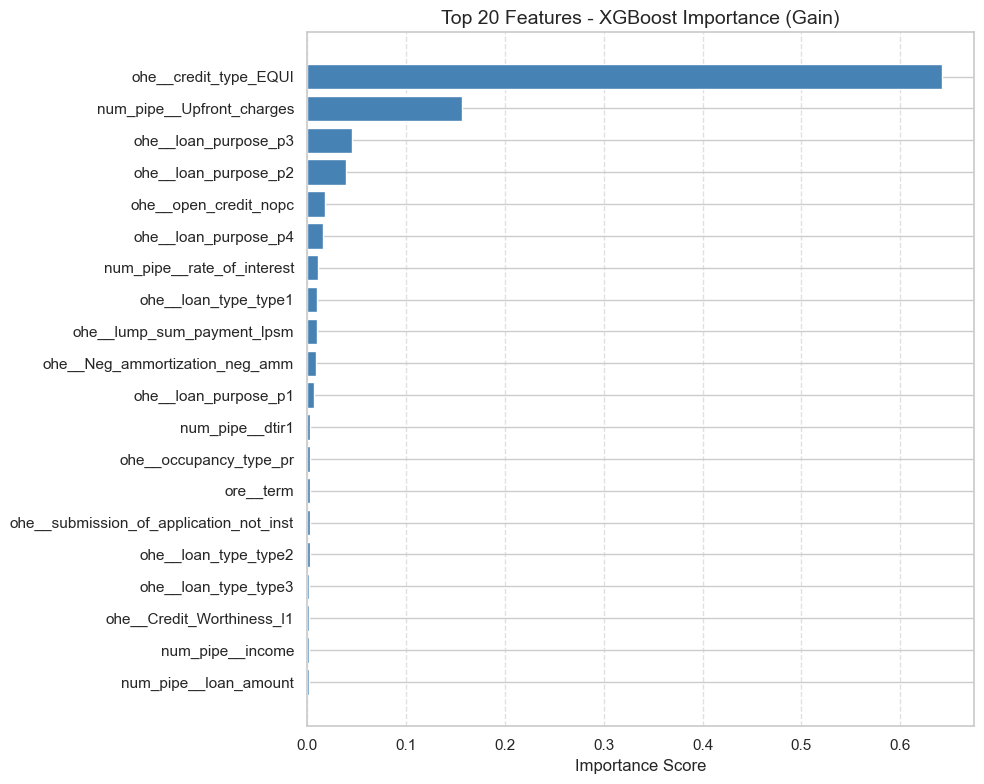

In [59]:

feat_names = xgb_pipe.named_steps['preprocessor'].get_feature_names_out()
fi = xgb_pipe.named_steps['model'].feature_importances_

# 2. Create DataFrame and sort
importance_df = pd.DataFrame({'Feature': feat_names, 'Importance': fi})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# 3. Sort ascending for the horizontal plot (so highest is at the top)
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# 4. Plot
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Top 20 Features - XGBoost Importance (Gain)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [60]:
tree_obtained_cols= ['credit_type', 'loan_purpose', 'Upfront_charges', 'open_credit','rate_of_interest',
                'loan_type', 'Neg_ammortization']

**Domain knowledge feature selection**

In [61]:
print(tree_obtained_cols)
print('-------------')
print(iv_obtained_cols)

['credit_type', 'loan_purpose', 'Upfront_charges', 'open_credit', 'rate_of_interest', 'loan_type', 'Neg_ammortization']
-------------
['Gender' 'loan_type' 'business_or_commercial' 'loan_amount'
 'rate_of_interest' 'Interest_rate_spread' 'Upfront_charges'
 'Neg_ammortization' 'property_value' 'income' 'credit_type'
 'co-applicant_credit_type' 'submission_of_application' 'LTV' 'dtir1']


In [62]:
dk_obtained_cols= ['loan_purpose', 'count']

In [63]:
final_cols= np.concatenate((iv_obtained_cols , dk_obtained_cols, ['Status']))

## EDA

In [64]:
df= df_new.loc[:, final_cols]

In [65]:
# examine imbalance
# outlier / transformations
# correlations

In [66]:
df['Status'].value_counts(normalize= True) #25% to 75% imbalance

Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64

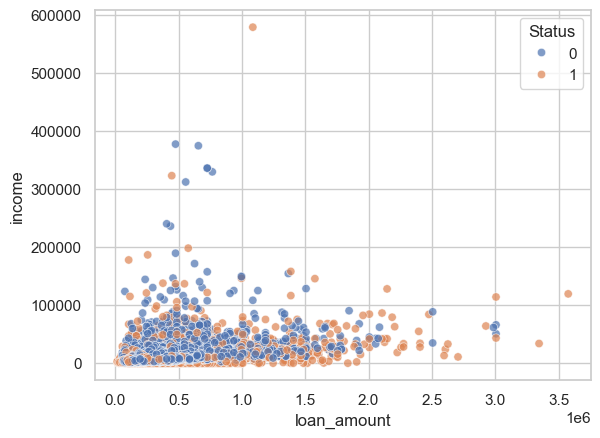

In [67]:
# loan_amount / income
plt.figure()
sns.scatterplot(data= df, x='loan_amount', y= 'income', hue= 'Status', alpha= .7)
plt.show()
# 3 outliers flagged person with above 400k income, and 2 with 3.2m loan_amount

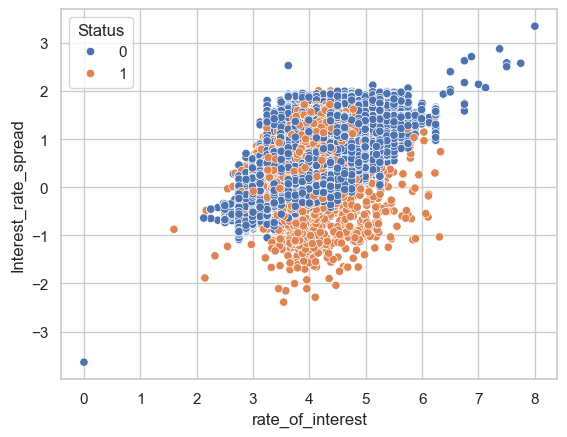

In [68]:
plt.figure()
sns.scatterplot(data= df, x= 'rate_of_interest', y= 'Interest_rate_spread', hue= 'Status')
plt.show()

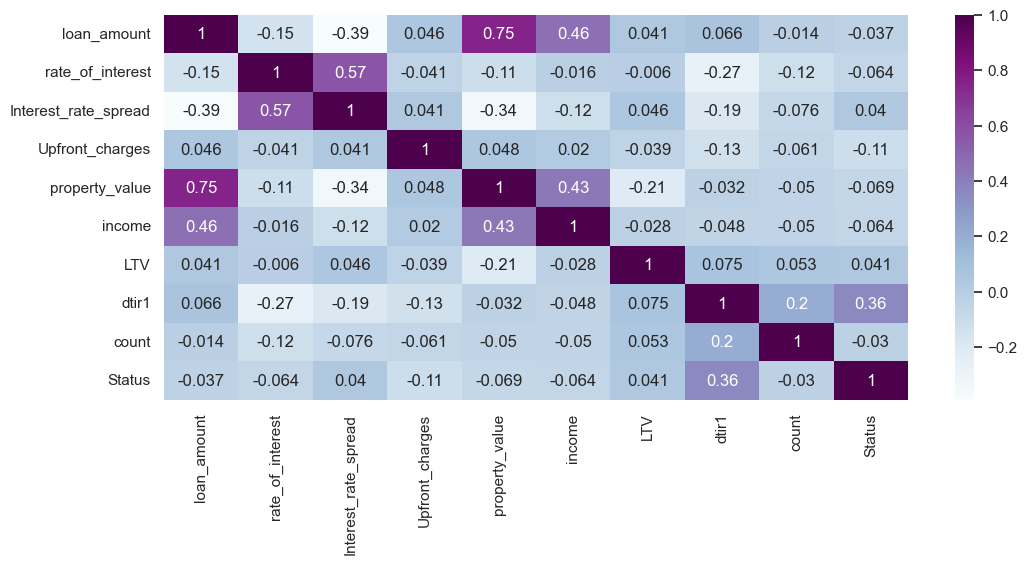

In [69]:
#heatmap
correlation= df.select_dtypes(include= 'number').corr()
plt.figure(figsize= (12, 5))
sns.heatmap(correlation, cmap= 'BuPu', annot= True)
plt.show()

dropping the property_value column (correlated with loan_amount) and captured by LTV

In [70]:
# plt.figure()
# sns.pairplot(df,palette='Dark2')
# plt.show()

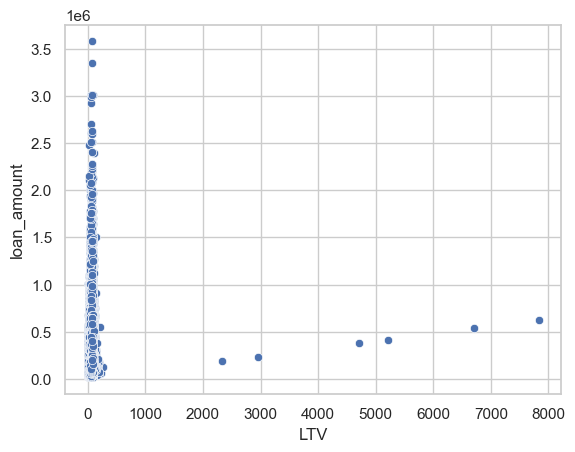

In [71]:
plt.figure()
sns.scatterplot(data= df, x= 'LTV', y='loan_amount')
plt.show()

**Handling Outliers**

In [72]:
outlier_indicies= []
# LTV beyond the 100%
mask= df['LTV'] > 105
outlier_indicies.extend(df.loc[mask, 'LTV'].index)
# income above 400k or 0
outlier_indicies.extend(df[df['income']>400_000].index)
outlier_indicies.extend(df[df['income'] == 0].index)
# loan_amount above 3.2M
outlier_indicies.extend(df[df['loan_amount']>3200_000].index)
# interest rate of 0
outlier_indicies.extend(df[df['rate_of_interest'] == 0].index)
# upfront charges > 40k
outlier_indicies.extend(df[df['Upfront_charges']> 40_000].index)
# property value > 10M
outlier_indicies.extend(df[df['property_value']> 10_000_000].index)

In [73]:
df= df.drop(list(set(outlier_indicies)))
df= df.reset_index(drop= True)

In [75]:
# clipping values
df['LTV']= df['LTV'].clip(upper= 100)
df['dtir1']= df['dtir1'].clip(upper= 100)

In [76]:
# models selection
# hyper establishment / stratified random grid search / learning curves / find best model
# fine tune its hyper space / stratified grid search / test on x_test
# perhaps try validations curves here, and play with other features engineering techniques
# hyper testing using metrics and optimize for one than the other
# include third party to enhance model inference

## Feature Engineering

In [77]:
# # Loan to income
# df['LTI']= df['loan_amount'] / df['income']
# dropping interest rate spread and upfront charges(determines after the risk assessment from the bank)
# dropping income (LTI explains it)

In [78]:
df_fe= df.copy()
df_fe['LTI']= df_fe['loan_amount']/df_fe['income']

In [79]:
df_fe.head(3)

,Gender,loan_type,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,Neg_ammortization,property_value,income,credit_type,co-applicant_credit_type,submission_of_application,LTV,dtir1,loan_purpose,count,Status,LTI
0,Sex Not Available,type1,nob/c,116500,4.322824,0.808717,1755.49,not_neg,118000.000000,1740.0,EXP,CIB,to_inst,98.728814,45.0,p1,1,1,66.954023
1,Male,type2,b/c,206500,3.981846,1.061626,1755.49,not_neg,277999.999998,4980.0,EQUI,EXP,to_inst,74.280576,100.0,p1,1,1,41.465863
2,Male,type1,nob/c,406500,4.560000,0.200000,595.00,neg_amm,508000.000000,9480.0,EXP,CIB,to_inst,80.019685,46.0,p1,1,0,42.879747


In [80]:
df[df['income']==0]

,Gender,loan_type,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,Neg_ammortization,property_value,income,credit_type,co-applicant_credit_type,submission_of_application,LTV,dtir1,loan_purpose,count,Status


In [81]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Select only numerical columns and drop the target ('Status')
numeric_df = df_fe.select_dtypes(include=['number']).drop(columns=['Status']).dropna()

# 2. Add a constant (intercept) - VIF requires this to be mathematically accurate
X = add_constant(numeric_df)

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                 feature         VIF
0                  const  152.252245
5         property_value    5.406512
1            loan_amount    4.902434
7                    LTV    2.397880
3   Interest_rate_spread    1.819858
2       rate_of_interest    1.623033
6                 income    1.389030
8                  dtir1    1.211928
9                  count    1.067503
4        Upfront_charges    1.053992
10                   LTI    1.049856


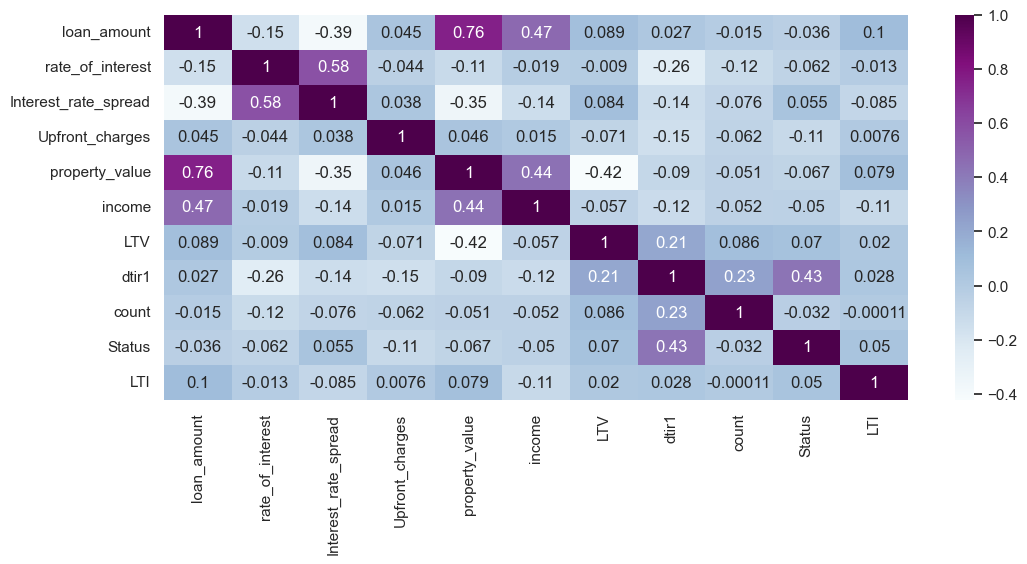

In [82]:
plt.figure(figsize= (12, 5))
sns.heatmap(df_fe.select_dtypes(include= 'number').corr(), cmap= 'BuPu', annot= True)
plt.show()

In [83]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
def lti_transform(col1, col2):
    return col1/col2
fe_pipe= Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('transformer', FunctionTransformer(lti_transform))
])

In [84]:
df_fe= df_fe.drop(['Interest_rate_spread','income','Upfront_charges'], axis= 1)

## Preprocessing

+ woe coarse classing
+ design pipelines for encoding

In [85]:
df_fe.columns

Index(['Gender', 'loan_type', 'business_or_commercial', 'loan_amount',
       'rate_of_interest', 'Neg_ammortization', 'property_value',
       'credit_type', 'co-applicant_credit_type', 'submission_of_application',
       'LTV', 'dtir1', 'loan_purpose', 'count', 'Status', 'LTI'],
      dtype='object')

In [86]:
df_fe.dtypes

Gender                        object
loan_type                     object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Neg_ammortization             object
property_value               float64
credit_type                   object
co-applicant_credit_type      object
submission_of_application     object
LTV                          float64
dtir1                        float64
loan_purpose                  object
count                          int64
Status                         int64
LTI                          float64
dtype: object

In [87]:
obj_variables= df_fe.select_dtypes(include= 'object').columns.tolist()
opt= BinningProcess(
    variable_names=df_fe.drop('Status',axis= 1).columns.tolist(),
    categorical_variables= obj_variables
)

In [88]:
woe_df= opt.fit_transform(df_fe.drop('Status',axis= 1), df_fe['Status'])

In [92]:
from sklearn.model_selection import train_test_split as tts
inputs= woe_df
target= df_fe['Status']
x_train, x_test, y_train, y_test= tts(inputs, target, test_size= .2,
                                      stratify= target, random_state= 22)

In [96]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Focus on the 'C' parameter (logarithmic scale)
# A tighter range around 0.01 to 1.0 is usually where the "sweet spot" is
param_grid = {
    'C': [0.001, 0.01, 0.1, 1,4,7,8,10,15,20,30],
    'penalty': ['l1','l2'], # L2 is faster and mathematically stable for WoE
    'solver': ['liblinear'] # 'lbfgs' is much faster for multi-core processing
}

# 2. Use a standard StratifiedKFold (No repeats = 3x faster)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Grid Search
grid_search = RandomizedSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    param_distributions=param_grid,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=-1 # Uses all your CPU cores
)

grid_search.fit(x_train, y_train)

print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best AUC: {grid_search.best_score_:.4f}")

Best C: 15
Best AUC: 0.8556


In [105]:
from sklearn.model_selection import RepeatedStratifiedKFold

param_grid= {
    'C': [14,14.5,15, 15.5,16],
    'solver': ['lbfgs'],
    'penalty': ['l2']
}

grid_search= GridSearchCV(
    estimator= LogisticRegression(class_weight= 'balanced', max_iter= 1000),
    param_grid= param_grid,
    cv= cv_strategy,
    n_jobs= -1
)

grid_search.fit(x_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 15, 'penalty': 'l2', 'solver': 'lbfgs'}
0.8148520276060776


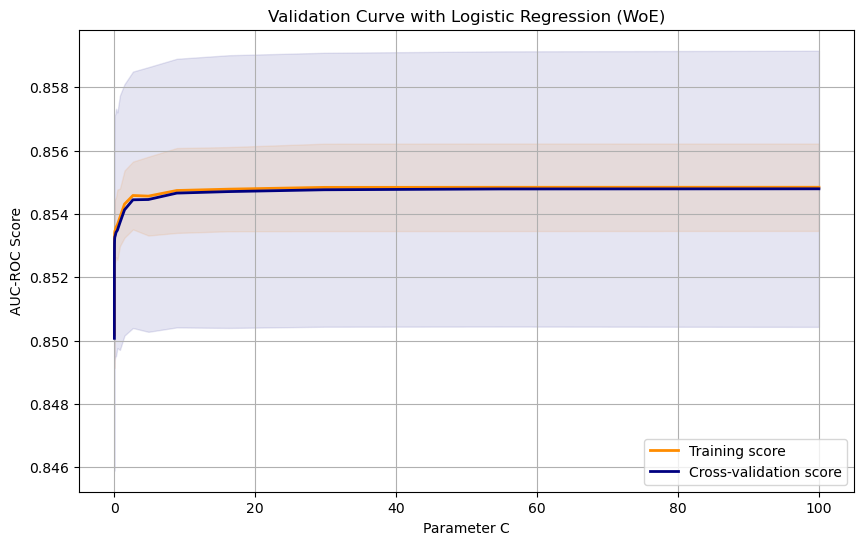

In [125]:
from sklearn.model_selection import validation_curve

# 1. Define the range from your code
param_range = np.logspace(-3, 2, 20)

# 2. Calculate scores
train_scores, test_scores = validation_curve(
    LogisticRegression(class_weight='balanced', max_iter=1000, penalty='l2', solver='lbfgs'),
    x_train, y_train, 
    param_name="C", 
    param_range=param_range,
    cv=cv_strategy, # Using your 10-split, 5-repeat strategy
    scoring="roc_auc", 
    n_jobs=-1
)

# 3. Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Training score", color="darkorange", lw=2)
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="darkorange")

plt.plot(param_range, test_mean, label="Cross-validation score", color="navy", lw=2)
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="navy")

plt.title("Validation Curve with Logistic Regression (WoE)")
plt.xlabel("Parameter C")
plt.ylabel("AUC-ROC Score")
plt.legend(loc="best")
plt.grid()
plt.show()

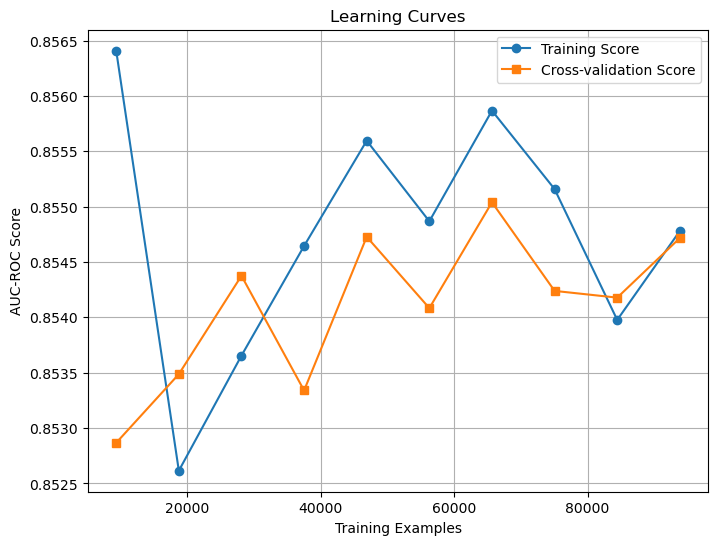

In [124]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_, x_train, y_train, cv=cv_strategy, scoring='roc_auc', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 's-', label="Cross-validation Score")
plt.xlabel("Training Examples")
plt.ylabel("AUC-ROC Score")
plt.title("Learning Curves")
plt.legend()
plt.grid()
plt.show()

<Figure size 640x480 with 0 Axes>

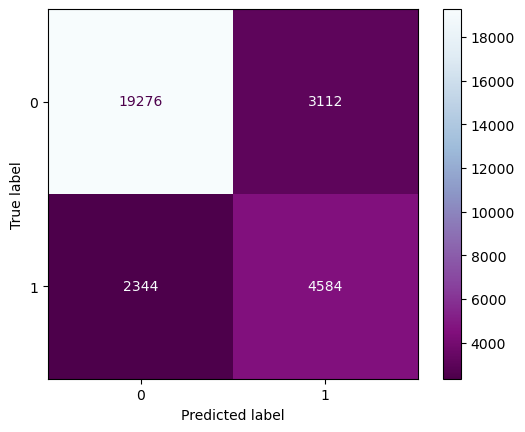

              precision    recall  f1-score   support

           0       0.89      0.86      0.88     22388
           1       0.60      0.66      0.63      6928

    accuracy                           0.81     29316
   macro avg       0.74      0.76      0.75     29316
weighted avg       0.82      0.81      0.82     29316



In [113]:
from sklearn.metrics import ConfusionMatrixDisplay as cmd, classification_report as cr,roc_curve,roc_auc_score
sns.reset_defaults()
plt.figure()
cmd.from_predictions(y_test, grid_search.predict(x_test), cmap= 'BuPu_r')
plt.show()
print(cr(y_test, grid_search.predict(x_test)))

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay


# 1. Calibrate the best model
best_model= LogisticRegression(**grid_search.best_params_)
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)
calibrated_model.fit(x_train, y_train)

,estimator,LogisticRegression(C=15)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,15
,fit_intercept,True
,intercept_scaling,1


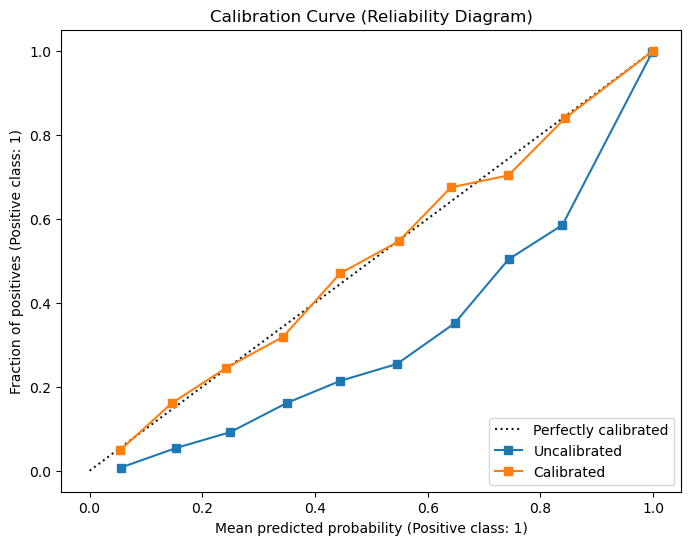

In [123]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Uncalibrated (Original Best Model)
CalibrationDisplay.from_estimator(grid_search.best_estimator_, x_test, y_test, n_bins=10, name='Uncalibrated', ax=ax)

# Plot Calibrated
CalibrationDisplay.from_estimator(calibrated_model, x_test, y_test, n_bins=10, name='Calibrated', ax=ax)

plt.title("Calibration Curve (Reliability Diagram)")
plt.show()

In [154]:
import pandas as pd
from sklearn.metrics import confusion_matrix

def threshold_analysis(y_true, y_probs, steps=100):
    results = []
    # Test thresholds from 0.1 to 0.9
    for t in np.linspace(0.1, 0.9, steps):
        preds = (y_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        
        # Calculate rates
        fpr = fp / (fp + tn) # Loans wrongly denied
        fnr = fn / (fn + tp) # Defaults wrongly approved
        
        results.append({
            "Threshold": round(t, 2),
            "Approved (TP+FP)": tn + fn,
            "Denied (TN+FN)": tp + fp,
            "False Positives (Wrongly Denied)": fp,
            "False Negatives (Missed Defaults)": fn,
            "FPR %": f"{fpr:.1%}",
            "FNR %": f"{fnr:.1%}"
        })
    
    return pd.DataFrame(results)

# Run it on your calibrated probabilities
analysis_df = threshold_analysis(y_test, calibrated_model.predict_proba(x_test)[:, 1])
print(analysis_df.to_string(index=False))

 Threshold  Approved (TP+FP)  Denied (TN+FN)  False Positives (Wrongly Denied)  False Negatives (Missed Defaults) FPR % FNR %
      0.10             10973           18343                             11959                                544 53.4%  7.9%
      0.11             11831           17485                             11194                                637 50.0%  9.2%
      0.12             12623           16693                             10493                                728 46.9% 10.5%
      0.12             13429           15887                              9791                                832 43.7% 12.0%
      0.13             14285           15031                              9063                                960 40.5% 13.9%
      0.14             15102           14214                              8385                               1099 37.5% 15.9%
      0.15             15882           13434                              7732                               1226 34.5

In [155]:
threshold= 0.15

In [181]:
# 1. Scaling Constants
pdo = 20
base_score = 600
base_odds = 50
factor = pdo / np.log(2)
offset = base_score - (factor * np.log(base_odds))

# 2. Extract Base Model Math
# Accessing the Logistic Regression inside the Calibration wrapper
actual_model = calibrated_model.calibrated_classifiers_[0].estimator
intercept = actual_model.intercept_[0]
features = list(x_train.columns)
n_vars = len(features)

# 3. Build Scorecard
scorecard_rows = []

for i, feat_name in enumerate(features):
    beta = actual_model.coef_[0][i]
    
    # Extract the binning table for this specific variable
    # This is the exact OptBinning method you requested
    table = opt.get_binned_variable(feat_name).binning_table.build()
    
    # We only care about rows that are actual bins (excluding 'Special', 'Missing', etc. if desired, 
    # but usually we include them if they have a WoE)
    # Filter out the 'Totals' row which OptBinning adds at the end
    table = table[table.index != 'Totals']
    
    for index, row in table.iterrows():
        woe_val = row['WoE']
        bin_label = row['Bin']
        
        # Scientific Point Formula
        # Points = ((WoE * Beta) + (Intercept / n)) * Factor + (Offset / n)
        pts = ((woe_val * beta) + (intercept / n_vars)) * factor + (offset / n_vars)
        
        scorecard_rows.append({
            "Variable": feat_name,
            "Bin": bin_label,
            "WoE": woe_val,
            "Points": round(pts, 0)
        })

scorecard_df = pd.DataFrame(scorecard_rows)
pd.options.display.max_rows= None
print(pd.DataFrame(scorecard_df))

                      Variable                     Bin        WoE  Points
0                       Gender                 [Joint]   0.322482    28.0
1                       Gender                [Female]  -0.033286    31.0
2                       Gender                  [Male]  -0.076616    31.0
3                       Gender     [Sex Not Available]  -0.202815    32.0
4                       Gender                 Special   0.000000    30.0
5                       Gender                 Missing   0.000000    30.0
6                    loan_type                 [type3]   0.092033    29.0
7                    loan_type                 [type1]   0.069259    29.0
8                    loan_type                 [type2]  -0.406558    37.0
9                    loan_type                 Special   0.000000    30.0
10                   loan_type                 Missing   0.000000    30.0
11      business_or_commercial                 [nob/c]   0.071773    30.0
12      business_or_commercial        

In [182]:
# Use the actual constants from your scorecard step
def p_to_score(p):
    p = np.clip(p, 0.0001, 0.9999)
    odds = (1 - p) / p  # Odds of being "Good"
    # Use the same factor and offset from the point calculation
    score = offset + (factor * np.log(odds))
    return int(score)

# Apply to results
df_final = pd.DataFrame(index=x_test.index)
df_final['PD'] = calibrated_model.predict_proba(x_test)[:, 1]
df_final['Score'] = df_final['PD'].apply(p_to_score)

In [184]:
df_final.head()

,PD,Score
47130,0.055399,568
134441,0.999944,221
116168,0.140850,539
85540,0.999908,221
134177,0.044622,575


In [194]:
df_fe.columns

Index(['Gender', 'loan_type', 'business_or_commercial', 'loan_amount',
       'rate_of_interest', 'Neg_ammortization', 'property_value',
       'credit_type', 'co-applicant_credit_type', 'submission_of_application',
       'LTV', 'dtir1', 'loan_purpose', 'count', 'Status', 'LTI'],
      dtype='object')

In [200]:
# EAD is usually the current loan amount plus any undisbursed funds.
# In this dataset, we'll use 'loan_amount' as our EAD.
df_final['EAD'] = df_fe['loan_amount']

# LGD Calculation based on LTV and Selling Costs (Haircut)
# Selling costs (legal fees, auction costs) are typically ~20% (0.2)
haircut = 0.20

# LGD = (Loan Amount - (Property Value * (1 - Haircut))) / Loan Amount
# We use .clip(0, 1) because LGD cannot be negative (a profit) or over 100%
df_final['LGD'] = (df_fe['loan_amount'] - (df_fe['property_value'] * (1 - haircut))) / df_fe['loan_amount']
df_final['LGD'] = df_final['LGD'].clip(0, 1)
# For 'unsecured' loans where property_value might be NaN or 0, we use a 45% proxy
df_final['LGD'] = df_final['LGD'].fillna(0.45)

In [201]:
df_final.head(8)

,PD,Score,EAD,LGD
47130,0.055399,568,256500,0.000000
134441,0.999944,221,136500,0.000000
116168,0.140850,539,296500,0.000000
85540,0.999908,221,396500,0.000000
134177,0.044622,575,486500,0.148201
125566,0.210783,525,346500,0.011833
58820,0.171669,532,276500,0.000000
81562,0.039515,579,426500,0.000000


In [202]:
# Calculate Expected Loss in Dollars
df_final['EL'] = df_final['PD'] * df_final['LGD'] * df_final['EAD']

# Summary of the portfolio risk
total_el = df_final['EL'].sum()
print(f"Total Expected Loss for Portfolio: ${total_el:,.2f}")

Total Expected Loss for Portfolio: $58,523,255.11


In [203]:
df_final.head(8)

,PD,Score,EAD,LGD,EL
47130,0.055399,568,256500,0.000000,0.000000
134441,0.999944,221,136500,0.000000,0.000000
116168,0.140850,539,296500,0.000000,0.000000
85540,0.999908,221,396500,0.000000,0.000000
134177,0.044622,575,486500,0.148201,3217.273681
125566,0.210783,525,346500,0.011833,864.210183
58820,0.171669,532,276500,0.000000,0.000000
81562,0.039515,579,426500,0.000000,0.000000


In [204]:
# 1. Portfolio Health Metrics
total_exposure = df_final['EAD'].sum()
total_provision = df_final['EL'].sum()
avg_pd = df_final['PD'].mean()

print(f"--- PORTFOLIO EXECUTIVE SUMMARY ---")
print(f"Total Portfolio Exposure: ${total_exposure:,.2f}")
print(f"Total Expected Loss (Provision): ${total_provision:,.2f}")
print(f"Portfolio Expected Loss Rate: {(total_provision / total_exposure):.2%}")
print(f"Average Probability of Default: {avg_pd:.2%}")

# 2. Risk Bucketing (Standard Banking Practice)
def risk_grade(score):
    if score >= 700: return 'A (Very Low Risk)'
    if score >= 600: return 'B (Low Risk)'
    if score >= 500: return 'C (Medium Risk)'
    return 'D (High Risk)'

df_final['Risk_Grade'] = df_final['Score'].apply(risk_grade)
summary_table = df_final.groupby('Risk_Grade').agg({
    'PD': 'mean',
    'EL': 'sum',
    'EAD': 'count'
}).rename(columns={'EAD': 'Loan_Count'})

print("\n--- RISK GRADE DISTRIBUTION ---")
print(summary_table)

--- PORTFOLIO EXECUTIVE SUMMARY ---
Total Portfolio Exposure: $9,718,724,000.00
Total Expected Loss (Provision): $58,523,255.11
Portfolio Expected Loss Rate: 0.60%
Average Probability of Default: 23.37%

--- RISK GRADE DISTRIBUTION ---
                       PD            EL  Loan_Count
Risk_Grade                                         
B (Low Risk)     0.012222  1.610014e+05        1553
C (Medium Risk)  0.137682  4.519040e+07       23381
D (High Risk)    0.824519  1.317185e+07        4382


In [205]:
# 1. Calculate Expected Revenue (Interest)
# Revenue = Loan Amount * Interest Rate
# We assume the interest rate is annual and applied to the EAD
df_final['Revenue'] = df_final['EAD'] * (df_fe['rate_of_interest'] / 100)

# 2. Calculate Net Profit per Loan
df_final['Net_Profit'] = df_final['Revenue'] - df_final['EL']

In [212]:
cut_offs = [221, 400, 450, 500,520,530, 550, 600, 650, 700]
analysis = []

for limit in cut_offs:
    # Approve everyone ABOVE the limit
    approved = df_final[df_final['Score'] >= limit]
    
    app_rate = len(approved) / len(df_final)
    total_rev = approved['Revenue'].sum()
    total_loss = approved['EL'].sum()
    net_val = total_rev - total_loss
    
    # Calculate False Negative Rate (FNR)
    # Scientifically: FNR is the % of "Bad" people we accidentally approved
    # (Assuming y_test is available to check actual defaults)
    actual_bads_approved = approved[y_test == 1].shape[0]
    total_bads = (y_test == 1).sum()
    fnr = actual_bads_approved / total_bads if total_bads > 0 else 0
    
    analysis.append({
        "Cut-off": limit,
        "Approval %": round(app_rate * 100, 1),
        "Net Profit ($)": round(net_val, 2),
        "FNR (%)": round(fnr * 100, 1)
    })

cutoff_df = pd.DataFrame(analysis)
print(cutoff_df)

   Cut-off  Approval %  Net Profit ($)  FNR (%)
0      221       100.0    3.289132e+08    100.0
1      400        90.4    2.952290e+08     59.3
2      450        90.3    2.952741e+08     58.9
3      500        85.1    2.904322e+08     47.6
4      520        75.0    2.736999e+08     35.6
5      530        65.0    2.513865e+08     26.1
6      550        38.1    1.656489e+08      8.2
7      600         5.3    2.788194e+07      0.1
8      650         0.0    3.853223e+05      0.0
9      700         0.0    0.000000e+00      0.0


C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\1824171350.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  actual_bads_approved = approved[y_test == 1].shape[0]
C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\1824171350.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  actual_bads_approved = approved[y_test == 1].shape[0]
C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\1824171350.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  actual_bads_approved = approved[y_test == 1].shape[0]
C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\1824171350.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  actual_bads_approved = approved[y_test == 1].shape[0]
C:\Users\mmopa\AppData\Local\Temp\ipykernel_17680\1824171350.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  actual_bads_approved = approved[y_test == 1].shape[0]


In [209]:
from sklearn.metrics import roc_auc_score

# Sort by Score to build the cumulative curve
df_sorted = df_final.copy()
df_sorted['actual_bad'] = y_test.values
df_sorted = df_sorted.sort_values('Score', ascending=False)

# Calculate Gini
auc = roc_auc_score(y_test, -df_final['Score'])
gini = 2 * auc - 1

# Plotting the Lorenz Curve
plt.plot(np.linspace(0, 1, len(df_sorted)), df_sorted['actual_bad'].cumsum() / df_sorted['actual_bad'].sum(), label='Cumulative Bads')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title(f'Lorenz Curve (Gini: {gini:.2f})')
plt.xlabel('Cumulative Population (Best to Worst)')
plt.ylabel('Cumulative Bads Found')
plt.legend()
plt.savefig('lorenz_curve.png')

In [210]:
# Test every score from min to max in steps of 5
cutoffs = np.arange(df_final['Score'].min(), df_final['Score'].max(), 5)
results = []

for c in cutoffs:
    approved = df_final[df_final['Score'] >= c]
    net_profit = approved['Revenue'].sum() - approved['EL'].sum()
    results.append(net_profit)

optimal_score = cutoffs[np.argmax(results)]

# Plotting the Sweet Spot
plt.plot(cutoffs, results, label='Net Profit', color='blue')
plt.axvline(optimal_score, color='red', linestyle='--', label=f'Optimal: {int(optimal_score)}')
plt.title('Profit Maximization')
plt.xlabel('Score Cut-off')
plt.ylabel('Total Net Profit ($)')
plt.legend()
plt.savefig('profit_maximization.png')

print(f"The Optimal Cut-off Score is: {int(optimal_score)}")

The Optimal Cut-off Score is: 221


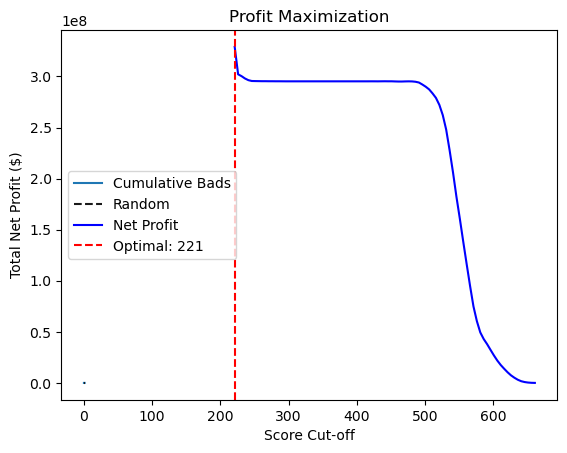

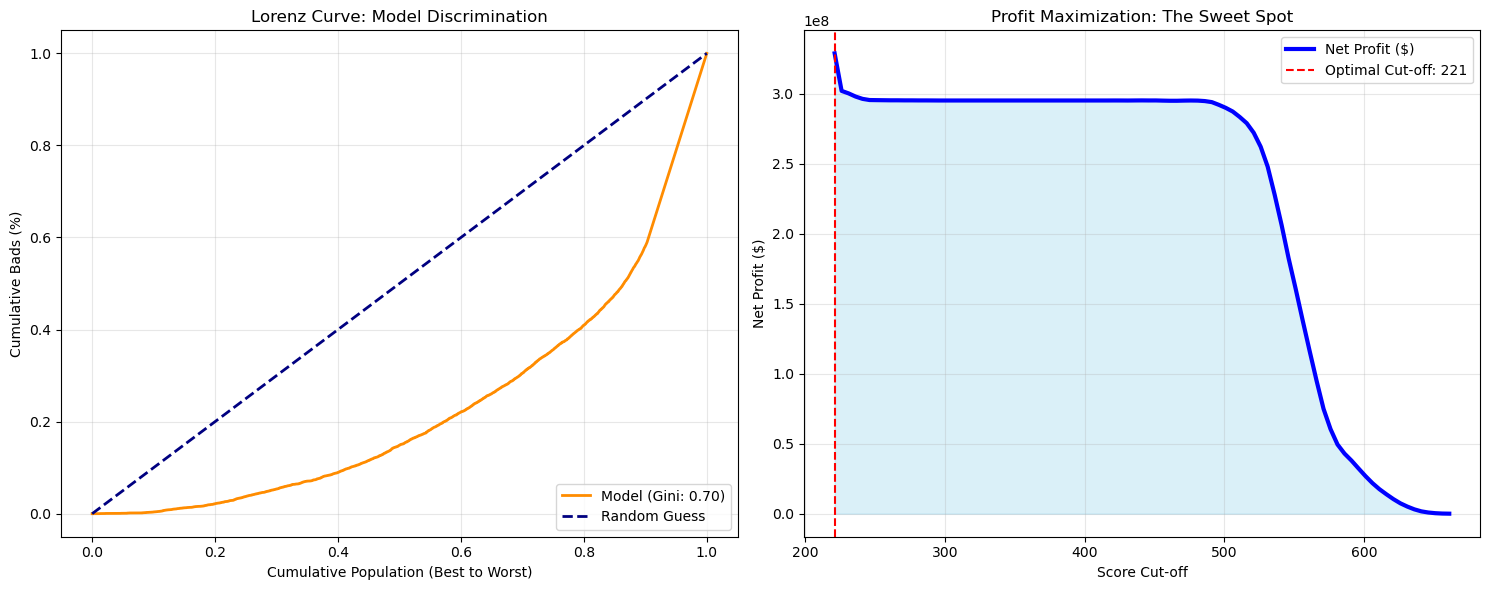

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP PLOT AREA
plt.figure(figsize=(15, 6))

# --- GRAPH 1: LORENZ CURVE (GINI) ---
plt.subplot(1, 2, 1)
df_sorted = df_final.copy()
df_sorted['actual_bad'] = y_test.values
df_sorted = df_sorted.sort_values('Score', ascending=False)

# Cumulative % calculations
pop_perc = np.linspace(0, 1, len(df_sorted))
bad_perc = df_sorted['actual_bad'].cumsum() / df_sorted['actual_bad'].sum()

plt.plot(pop_perc, bad_perc, color='darkorange', lw=2, label=f'Model (Gini: {gini:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.title('Lorenz Curve: Model Discrimination')
plt.xlabel('Cumulative Population (Best to Worst)')
plt.ylabel('Cumulative Bads (%)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# --- GRAPH 2: PROFIT MAXIMIZATION ---
plt.subplot(1, 2, 2)
plt.plot(cutoffs, results, color='blue', lw=3, label='Net Profit ($)')
plt.axvline(optimal_score, color='red', linestyle='--', label=f'Optimal Cut-off: {int(optimal_score)}')

# Visualizing the "Danger Zone"
plt.fill_between(cutoffs, results, color='skyblue', alpha=0.3)
plt.title('Profit Maximization: The Sweet Spot')
plt.xlabel('Score Cut-off')
plt.ylabel('Net Profit ($)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()